# 1. Understanding the Structure of the Data

Check column names, data types(int, float, object), number of raws, and missing values.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Customer-Churn-Records.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

Observation:
1. There are 18 columns and 10000 rows.
2. There is no null data.
3. 4 object data (Card type, Gender, Geography, Surname), and rest of them are integer or float.

# 2. Assess Data Quality

1. Detect missing values -> decide whether to impute or drop them.
2. Identify outliers -> decide whether to remove or adjust them.
3. Find duplicate rows or inconsistent entries.

In [ ]:
df.isnull().sum() # detecting missing values

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.describe().round(2) # identify outliers

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.0,10000.00,10000.00
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2,0.2,3.01,606.52
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4,0.4,1.41,225.92
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0,0.0,1.00,119.00
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0,0.0,2.00,410.00
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0,0.0,3.00,605.00
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0,0.0,4.00,801.00
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0,1.0,5.00,1000.00


In [ ]:
df.duplicated().sum() # find duplicate rows or inconsistent entries

np.int64(0)

Observaton: There is no missing values, outliners, dulicate rows -> clean data.

# 3. Explore Variable Distributions

Explore data and divide features into two categories. (numerical or categorical)
And then

If it is **numerical feature** -> explore mean, standard deviation, distribution shape.
If it is **categorical feature** -> explore frequency counts, proportions(value_counts, bar plots).

In [ ]:
# Unique value counts
for i in df.columns:
    print(df[i].value_counts())
    print("\n--------------\n")

RowNumber
9984    1
9983    1
9982    1
9981    1
9980    1
       ..
5       1
4       1
3       1
2       1
1       1
Name: count, Length: 10000, dtype: int64

--------------

CustomerId
15656710    1
15768163    1
15672754    1
15719276    1
15692664    1
           ..
15737888    1
15701354    1
15619304    1
15647311    1
15634602    1
Name: count, Length: 10000, dtype: int64

--------------

Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Hull          1
Sturdee       1
Flannagan     1
Dwyer         1
Corby         1
Name: count, Length: 2932, dtype: int64

--------------

CreditScore
850    233
678     63
655     54
705     53
667     53
      ... 
358      1
412      1
382      1
373      1
419      1
Name: count, Length: 460, dtype: int64

--------------

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

--------------

Gender
Male      5457
Female    4543
Name: count, dtype: int64

----

Observation:
RowNumber	CustomerId	Surname	CreditScore	Geography	Gender	Age	Tenure	Balance	NumOfProducts	HasCrCard	IsActiveMember	EstimatedSalary	Exited	Complain	Satisfaction Score	Card Type	Point Earned
1. Numerical feature ->
CreditScore, Age, Tenure, Balance, NumOfProducts, EstimatedSalary, Satisfaction Score, Point Earned
2. Categorical feature ->
Geography, Gender, HasCrCard, IsActiveMember, Exited, Complain, Card Type,
3. features to be deleted -> RowNumber, CustomerId, Surname

In [ ]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [ ]:
categorical = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Exited', 'Complain', 'Card Type']
numerical = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']

1. Numerical Features Distribution

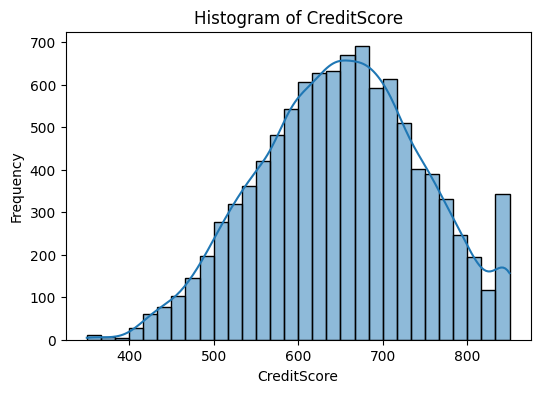

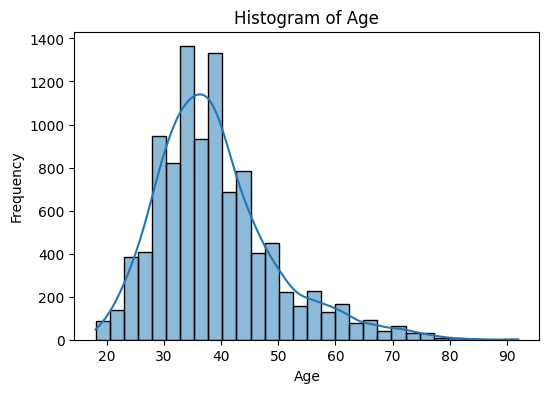

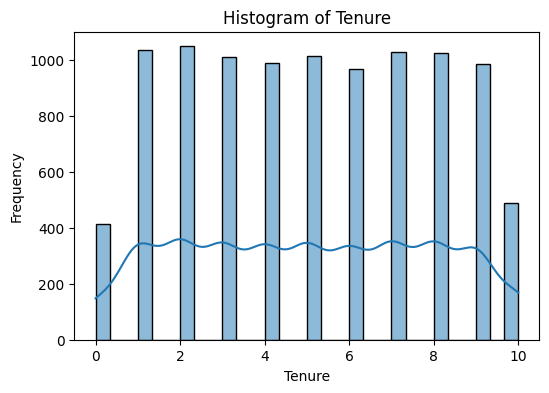

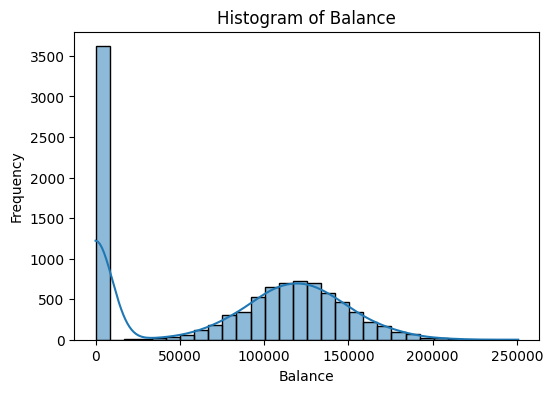

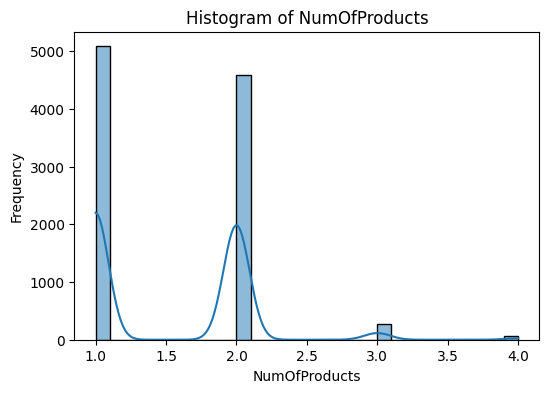

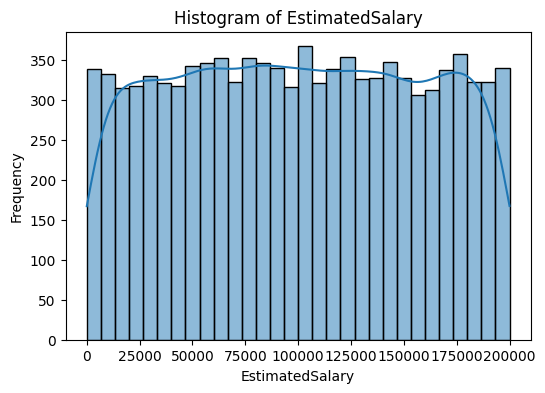

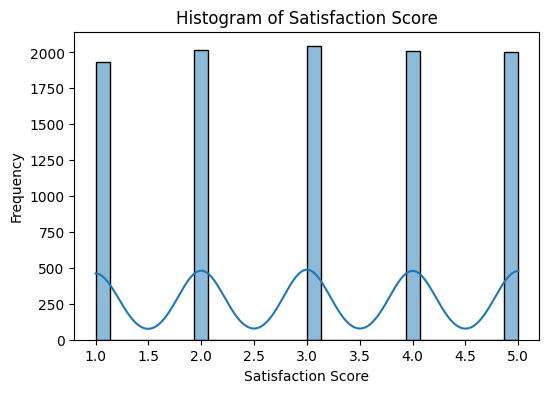

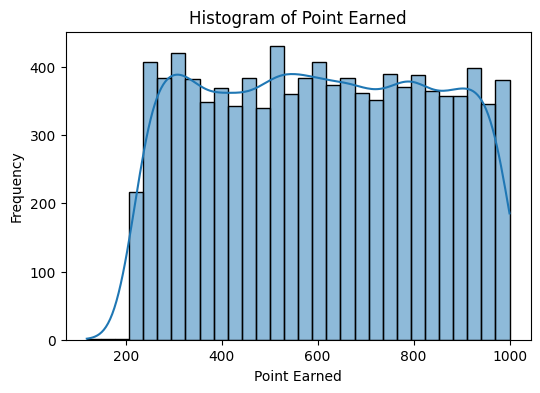

In [ ]:
for col in numerical:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

2. Categorical Features Distribution

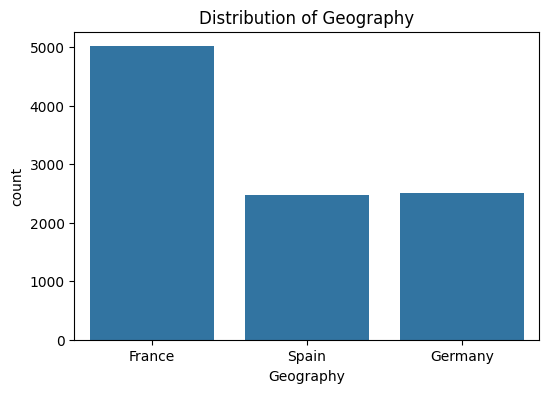

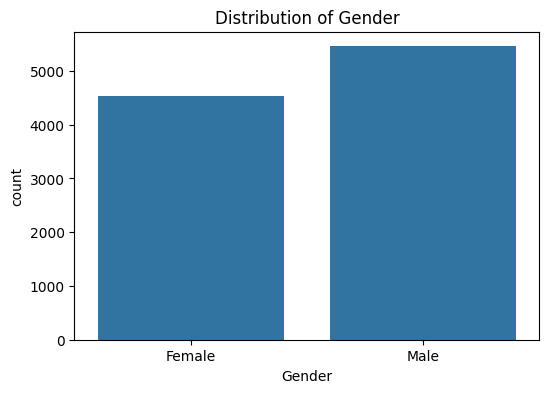

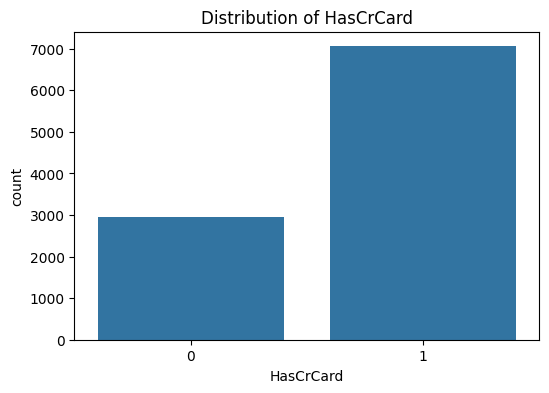

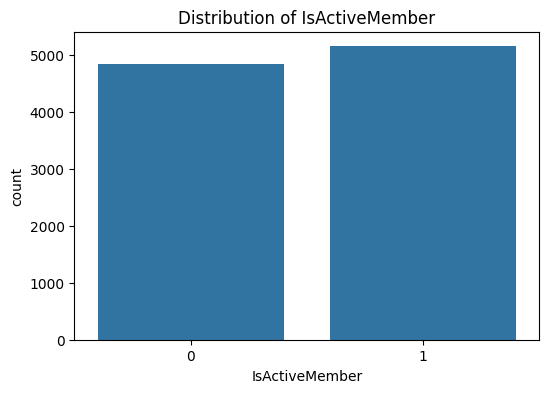

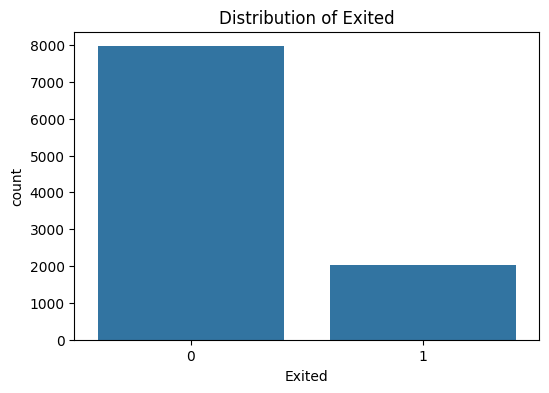

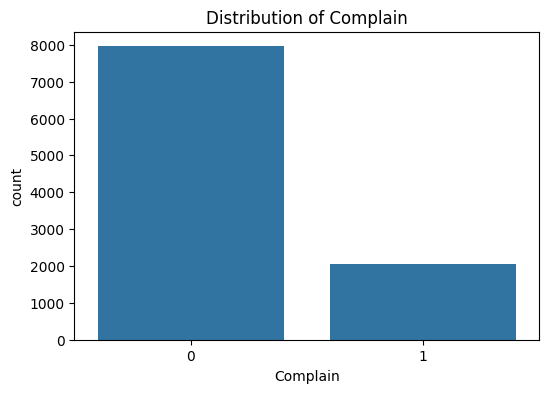

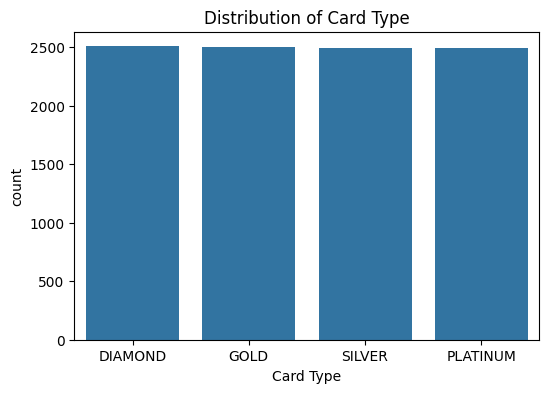

In [ ]:
for col in categorical:
    plt.figure(figsize=(6, 4))
    sns.countplot(x = col, data = df)
    plt.title(f"Distribution of {col}")
    plt.show()

# 4. Investigate Relationships Between Variables

numerical vs numerical -> correlation matrix and heatmap -> choose some and do scatter plot

categorical vs numerical -> with target boxplots

categorical vs categorical -> stacked bar chart (countplot with hue)

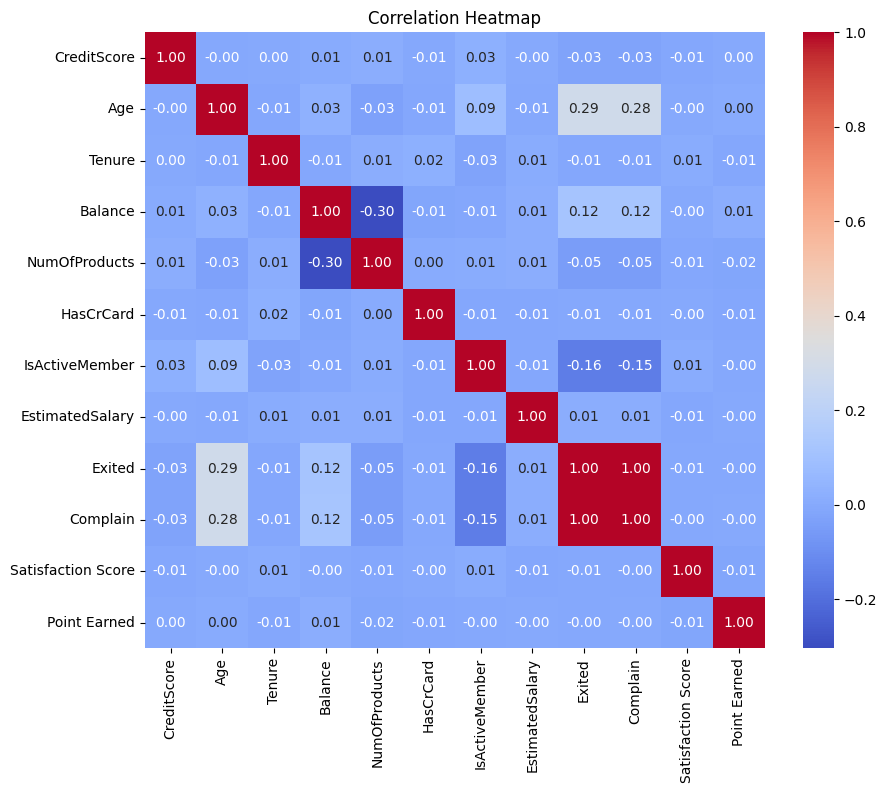

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
target_corr = corr["Exited"].sort_values(ascending=False)
print(target_corr)

Exited                1.000000
Complain              0.995693
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
HasCrCard            -0.006976
Tenure               -0.013656
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64


In [ ]:
candidates = df[["Complain", "Age"]]

In [ ]:
candidates

,Complain,Age
0,1,42
1,1,41
2,1,42
3,0,39
4,0,43
...,...,...
9995,0,39
9996,0,35
9997,1,36
9998,1,42


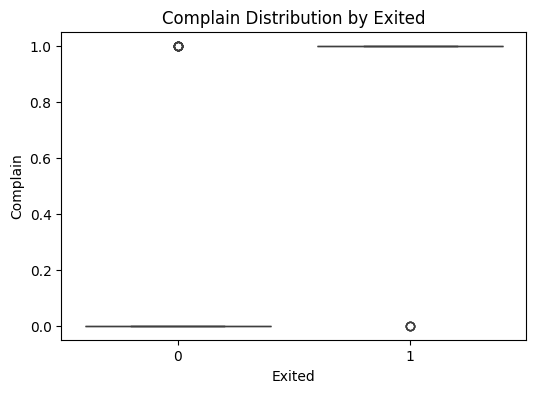

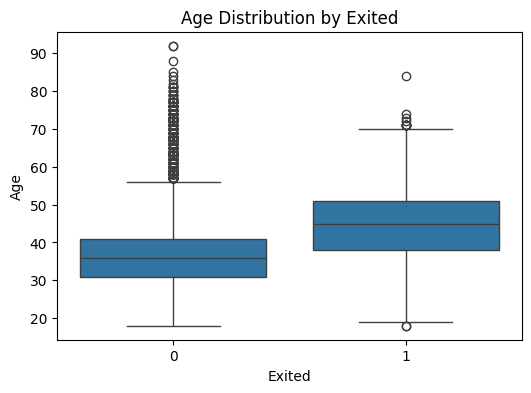

In [ ]:
for col in candidates:
    plt.figure(figsize=(6,4))
    sns.boxplot(y= col, x="Exited", data=df)
    plt.title(f"{col} Distribution by Exited")
    plt.show()

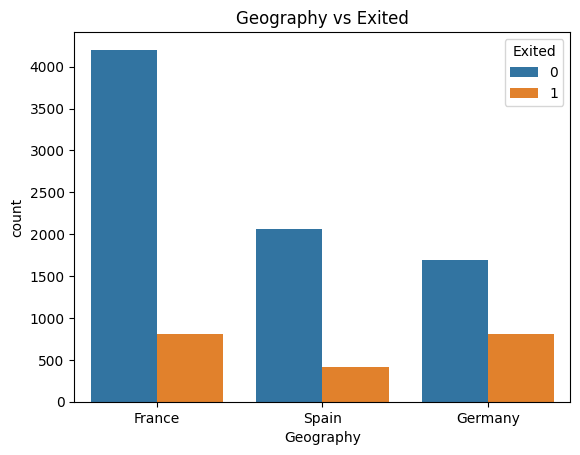

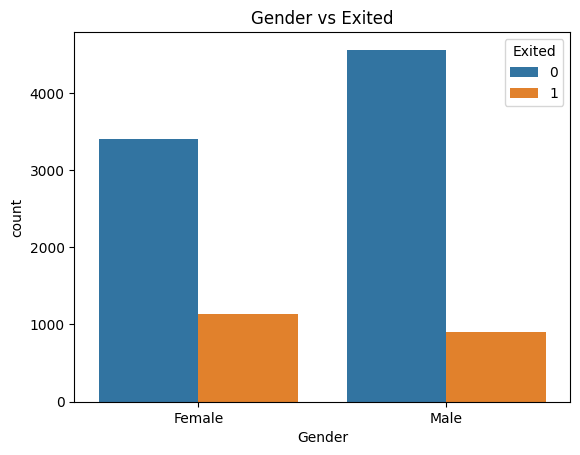

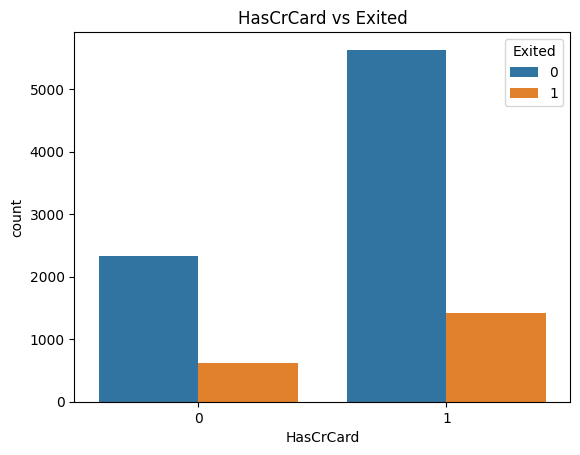

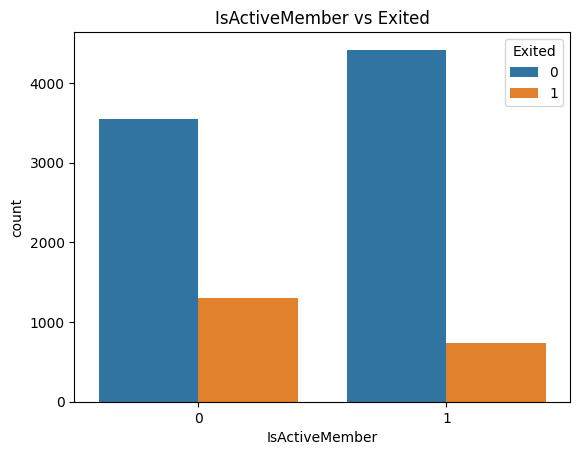

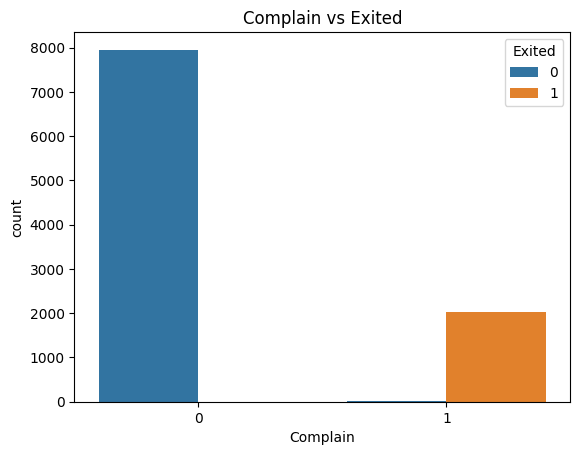

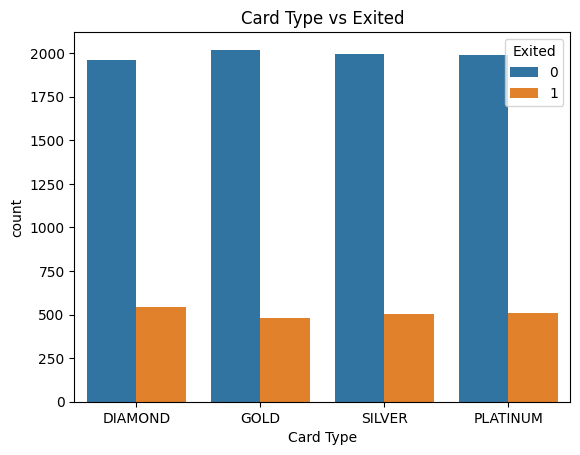

In [ ]:
categorical.remove("Exited")
for col in categorical:
    sns.countplot(x= col, hue= "Exited", data = df)
    plt.title(f"{col} vs Exited")
    plt.show()

Observation: This analysis indicates that top correlated features are Complain and Age.
The analysis shows that higher Complain is strongly associated with a higher likelihood of Exit.

This suggests that managing customer's complain may play important roles in preventing cusotmer's exit.

# 5. ML Modeling

In [ ]:
# Drop 'Complain' due to its extremely high correlation with the target
# which indicates potential target leakage.
df = df.drop(['Complain'], axis=1)

OneHot Encoder
Here we use OneHot Encoder to transform the categorical variables into continuous variables.

In [ ]:
data = pd.get_dummies(df, columns = ['Geography', 'Gender', 'Card Type'], drop_first = True)

In [ ]:
data.head() #checking dummies

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,1,2,464,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,3,456,False,True,False,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,3,377,False,False,False,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,5,350,False,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,5,425,False,True,False,True,False,False


Chose two models (Logistic Regression and RandomForest)
Starting with Logistic
1. Regression to establish a clear and interpretable baseline for the chrun prediction task.
2. Training a RandomForest model to capture non-linear relationships and compare performance.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = data.drop('Exited', axis=1)
y = data['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=100)


In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=100
    )
}

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    print(f"{name} - Accuracy: {acc:.4f}, ROC-AUC: {auc:.4f}")



Training Logistic Regression...
Logistic Regression - Accuracy: 0.8030, ROC-AUC: 0.7561

Training Random Forest...
Random Forest - Accuracy: 0.8535, ROC-AUC: 0.8477


In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print("\nClassification Report for Random Forest:")
print(classification_report(y_test, rf_pred))


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1587
           1       0.78      0.40      0.53       413

    accuracy                           0.85      2000
   macro avg       0.82      0.69      0.72      2000
weighted avg       0.85      0.85      0.83      2000



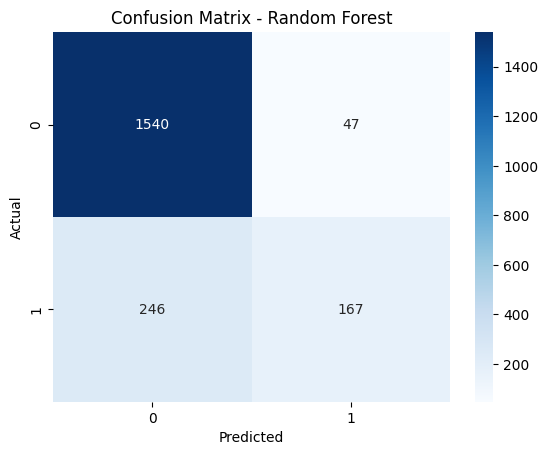

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Model Comparison Table

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    results.append([name, acc, auc])

pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.8030,0.756110
1,Random Forest,0.8535,0.847677
